In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.utils import to_categorical

In [2]:
DATASET_PATH = "leapGestRecog"

IMG_SIZE = 64

X = []
y = []

In [3]:
gesture_folders = sorted(
    os.listdir(
        os.path.join(DATASET_PATH, "00")
    )
)

print("Gesture Classes:")
print(gesture_folders)

for label, gesture in enumerate(gesture_folders):

    for person in sorted(os.listdir(DATASET_PATH)):

        person_path = os.path.join(DATASET_PATH, person)

        if not os.path.isdir(person_path):
            continue

        gesture_path = os.path.join(
            person_path,
            gesture
        )

        if not os.path.exists(gesture_path):
            continue

        for image_name in os.listdir(gesture_path):

            try:

                img_path = os.path.join(
                    gesture_path,
                    image_name
                )

                image = cv2.imread(img_path)

                image = cv2.resize(
                    image,
                    (IMG_SIZE, IMG_SIZE)
                )

                X.append(image)
                y.append(label)

            except:
                pass

Gesture Classes:
['01_palm', '02_l', '03_fist', '04_fist_moved', '05_thumb', '06_index', '07_ok', '08_palm_moved', '09_c', '10_down']


In [4]:
X = np.array(X, dtype=np.float32) / 255.0
y = np.array(y)

print("Total Images:", len(X))
print("Total Classes:", len(np.unique(y)))

Total Images: 20000
Total Classes: 10


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 16000
Testing Samples: 4000


In [6]:
num_classes = 10

y_train = to_categorical(
    y_train,
    num_classes
)

y_test = to_categorical(
    y_test,
    num_classes
)

In [7]:
model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(64,64,3)
    )
)

model.add(BatchNormalization())

model.add(
    MaxPooling2D(
        pool_size=(2,2)
    )
)

model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(BatchNormalization())

model.add(
    MaxPooling2D(
        pool_size=(2,2)
    )
)

model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu'
    )
)

model.add(BatchNormalization())

model.add(
    MaxPooling2D(
        pool_size=(2,2)
    )
)

model.add(Flatten())

model.add(
    Dense(
        256,
        activation='relu'
    )
)

model.add(
    Dropout(0.5)
)

model.add(
    Dense(
        128,
        activation='relu'
    )
)

model.add(
    Dropout(0.3)
)

model.add(
    Dense(
        10,
        activation='softmax'
    )
)

C:\Users\mrpar\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 62, 62, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 29, 29, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 12, 12, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 12, 12, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 4608)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       1,179,904 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,308,234 (4.99 MB)

 Trainable params: 1,307,786 (4.99 MB)

 Non-trainable params: 448 (1.75 KB)

In [9]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_data=(
        X_test,
        y_test
    )
)

Epoch 1/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 50s 95ms/step - accuracy: 0.7733 - loss: 0.7067 - val_accuracy: 0.8330 - val_loss: 0.5110
Epoch 2/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 49s 97ms/step - accuracy: 0.9685 - loss: 0.1074 - val_accuracy: 0.9977 - val_loss: 0.0067
Epoch 3/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 45s 89ms/step - accuracy: 0.9811 - loss: 0.0699 - val_accuracy: 0.9898 - val_loss: 0.0375
Epoch 4/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 44s 87ms/step - accuracy: 0.9865 - loss: 0.0496 - val_accuracy: 0.9985 - val_loss: 0.0064
Epoch 5/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 43s 86ms/step - accuracy: 0.9871 - loss: 0.0532 - val_accuracy: 1.0000 - val_loss: 3.4004e-04
Epoch 6/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 43s 86ms/step - accuracy: 0.9911 - loss: 0.0379 - val_accuracy: 0.9995 - val_loss: 0.0019
Epoch 7/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 45s 89ms/step - accuracy: 0.9937 - loss: 0.0303 - val_accuracy: 0.9990 - val_loss: 0.0032
Epoch 8/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 46s 91ms/step - accuracy: 0.9942 - loss: 0.024

In [11]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print(
    f"Test Accuracy: {accuracy*100:.2f}%"
)

125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9998 - loss: 5.6487e-04
Test Accuracy: 99.98%


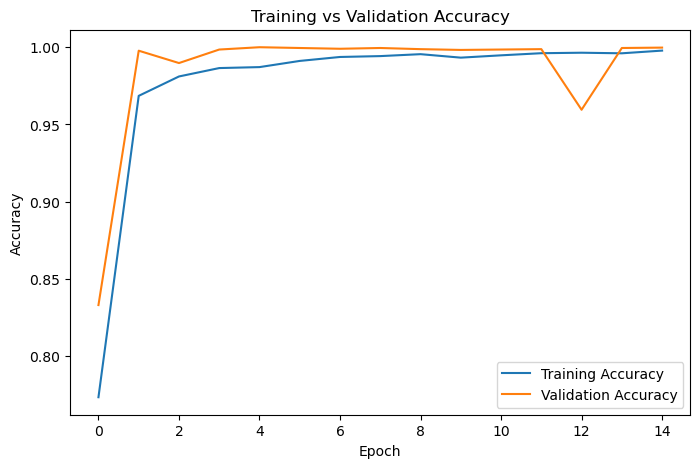

In [12]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title(
    'Training vs Validation Accuracy'
)

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend()

plt.show()

In [13]:
model.save(
    "hand_gesture_model_new.h5"
)

print(
    "Model Saved Successfully!"
)

Model Saved Successfully!


In [15]:
gesture_names = [
    "Palm",
    "L",
    "Fist",
    "Fist Moved",
    "Thumb",
    "Index",
    "OK",
    "Palm Moved",
    "C",
    "Down"
]

image_path = "C:/Users/mrpar/PRODIGY_ML_03/Task_04/frame_00_05_0001.png"

img = cv2.imread(image_path)

img = cv2.resize(
    img,
    (64,64)
)

img = img.astype(
    np.float32
) / 255.0

img = np.expand_dims(
    img,
    axis=0
)

prediction = model.predict(img)

class_id = np.argmax(
    prediction
)

print(
    "Prediction:",
    gesture_names[class_id]
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
Prediction: Thumb


In [16]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model

model = load_model(
    "hand_gesture_model.h5"
)

gesture_names = [
    "Palm",
    "L",
    "Fist",
    "Fist Moved",
    "Thumb",
    "Index",
    "OK",
    "Palm Moved",
    "C",
    "Down"
]

cap = cv2.VideoCapture(0)

while True:

    ret, frame = cap.read()

    if not ret:
        break

    x1, y1 = 100, 100
    x2, y2 = 300, 300

    roi = frame[y1:y2, x1:x2]

    img = cv2.resize(
        roi,
        (64,64)
    )

    img = img.astype(
        np.float32
    ) / 255.0

    img = np.expand_dims(
        img,
        axis=0
    )

    prediction = model.predict(
        img,
        verbose=0
    )

    class_id = np.argmax(
        prediction
    )

    confidence = (
        np.max(prediction) * 100
    )

    gesture = gesture_names[class_id]

    cv2.rectangle(
        frame,
        (x1,y1),
        (x2,y2),
        (0,255,0),
        2
    )

    cv2.putText(
        frame,
        f"{gesture} ({confidence:.1f}%)",
        (40,70),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0,255,0),
        2
    )

    cv2.imshow(
        "Hand Gesture Recognition",
        frame
    )

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

KeyboardInterrupt: 